<a href="https://colab.research.google.com/github/faizaan0619/MachineLearning/blob/main/Supervised/SVC_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

In [ ]:
X = mnist.data[:1000]
y = mnist.target[:1000]

In [ ]:
print(X.shape)
print(y.shape)

(1000, 784)
(1000,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.svm import SVC
model = SVC(kernel="linear", C=10)

In [ ]:
import time
start = time.time()
model.fit(X_train, y_train)
end = time.time()
print(end-start)

0.09673047065734863


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.875

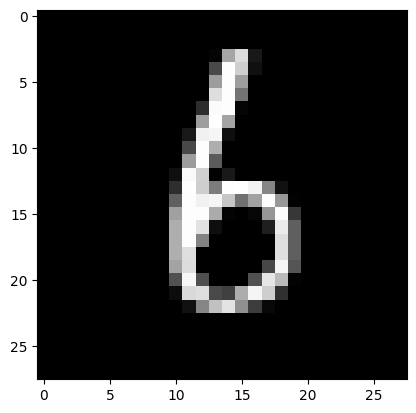

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(X_test[3].reshape(28, 28), cmap="gray")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {"C": [0.1, 1, 10, 100], "kernel": ["linear", "rbf"]}
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring="accuracy")

In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [ ]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'C': 10, 'kernel': 'rbf'}
0.9075


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=10))
])

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', SVC(C=10))])

In [ ]:
y_pred = pipeline.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred)

0.855

In [ ]:
import numpy as np
correct_indices = np.where(y_pred == y_test)[0]
incorrect_indices = np.where(y_pred != y_test)[0]

print(f"Number of correctly classified samples: {len(correct_indices)}")
print(f"Number of incorrectly classified samples: {len(incorrect_indices)}")

Number of correctly classified samples: 171
Number of incorrectly classified samples: 29


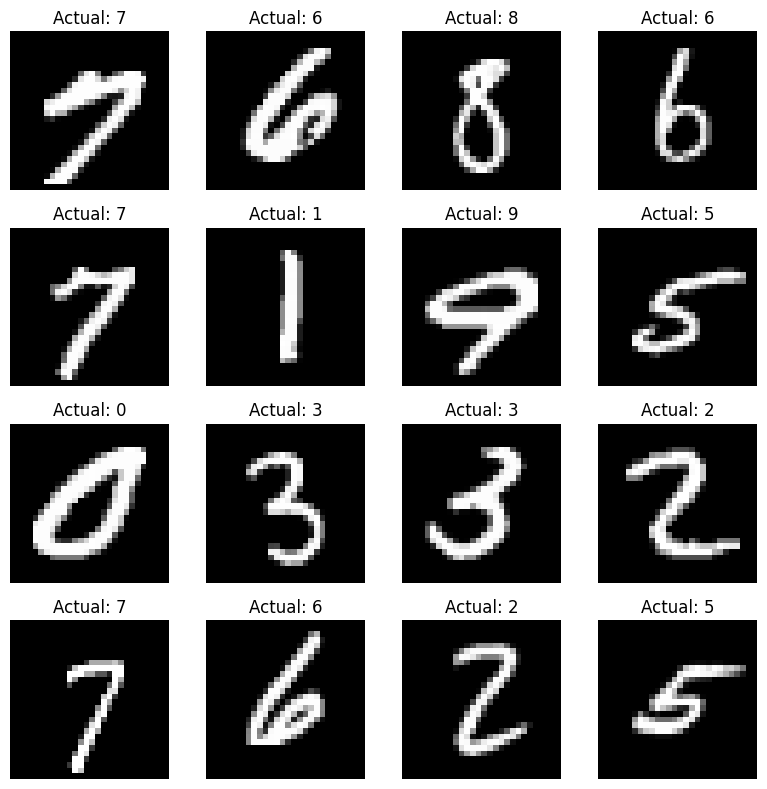

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Actual: {y_test[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()